In [1]:
!pip install -q kagglehub transformers sentence-transformers \
             spacy gensim nltk scikit-learn xgboost \
             wordcloud PyPDF2 python-docx

!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 45.3 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import kagglehub, os, re, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

# ── NLTK ─────────────────────────────────────────────────────
import nltk
for pkg in ['punkt','stopwords','wordnet','averaged_perceptron_tagger',
            'maxent_ne_chunker','words','punkt_tab','omw-1.4']:
    nltk.download(pkg, quiet=True)

from nltk.corpus    import stopwords
from nltk.stem      import WordNetLemmatizer
from nltk.tokenize  import word_tokenize, sent_tokenize
import nltk.chunk

# ── spaCy ────────────────────────────────────────────────────
import spacy
nlp_spacy = spacy.load('en_core_web_sm')

# ── Sklearn ───────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise        import cosine_similarity
from sklearn.preprocessing           import LabelEncoder, StandardScaler
from sklearn.model_selection         import train_test_split, cross_val_score
from sklearn.ensemble                import RandomForestClassifier
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.calibration             import CalibratedClassifierCV
from sklearn.metrics                 import (accuracy_score,
                                              classification_report,
                                              confusion_matrix)

# ── Gensim ───────────────────────────────────────────────────
from gensim.models import Word2Vec

# ── Transformers ─────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
import torch
import torch.nn.functional as F
from transformers import (BertTokenizer,
                           BertModel,
                           pipeline)

# ── WordCloud ────────────────────────────────────────────────
try:
    from wordcloud import WordCloud
    WC = True
except:
    WC = False

# ── TensorFlow ───────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils     import to_categorical

STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

print("All imports done!")
print(f"   TF      : {tf.__version__}")
print(f"   PyTorch : {torch.__version__}")

✅ All imports done!
   TF      : 2.20.0
   PyTorch : 2.10.0+cu128


In [3]:
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
print("Path:", path)

for root, _, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

Path: /kaggle/input/datasets/snehaanbhawal/resume-dataset
/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/22506245.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/13998435.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/67582956.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/34349255.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/26790545.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/12674307.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11807040.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/44145704.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/27497542.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11155153.pdf
/kaggle/input/datasets/snehaanbh

In [4]:
csv_path = os.path.join(path, "Resume", "Resume.csv")

# Try alternate path
if not os.path.exists(csv_path):
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith('.csv'):
                csv_path = os.path.join(root, f)
                break

df = pd.read_csv(csv_path)
print("Shape  :", df.shape)
print("Columns:", df.columns.tolist())
print("\nCategories:")
print(df['Category'].value_counts())
df.head(3)

Shape  : (2484, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [5]:
print(df.info())

print(df.isnull().sum())

print(f"\nTotal Resumes   : {len(df)}")
print(f"Job Categories  : {df['Category'].nunique()}")
print(f"Categories      : {df['Category'].unique().tolist()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Total Resumes   : 2484
Job Categories  : 24
Categories      : ['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE', 'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE', 'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE', 'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT', 'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION']


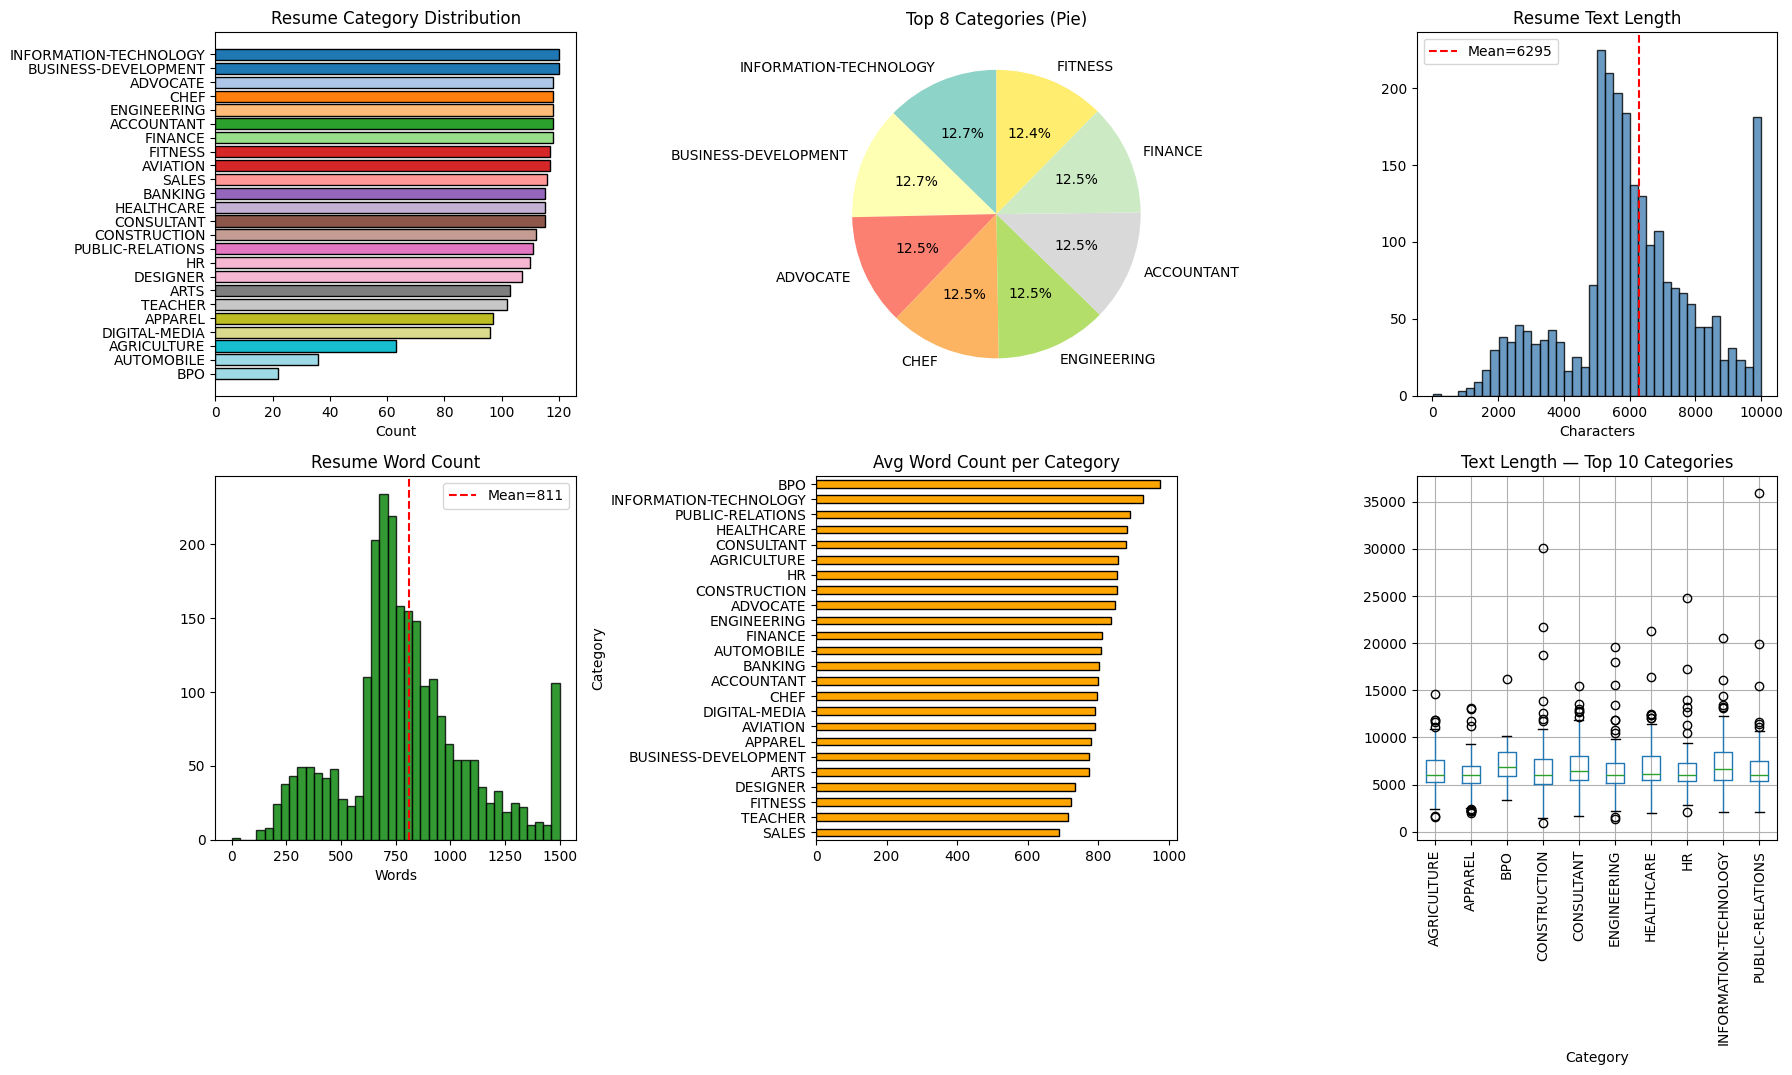

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Resume Dataset — EDA', fontsize=16, fontweight='bold')

# 6a. Category distribution
cat_counts = df['Category'].value_counts()
colors     = plt.cm.tab20(np.linspace(0, 1, len(cat_counts)))
axes[0,0].barh(cat_counts.index, cat_counts.values,
               color=colors, edgecolor='black')
axes[0,0].set_title('Resume Category Distribution')
axes[0,0].set_xlabel('Count')
axes[0,0].invert_yaxis()

# 6b. Pie chart (top 8)
top8 = cat_counts.head(8)
axes[0,1].pie(top8.values, labels=top8.index,
              autopct='%1.1f%%', startangle=90,
              colors=plt.cm.Set3(np.linspace(0,1,8)))
axes[0,1].set_title('Top 8 Categories (Pie)')

# 6c. Resume text length
df['text_len'] = df['Resume_str'].astype(str).apply(len)
axes[0,2].hist(df['text_len'].clip(upper=10000),
               bins=40, color='steelblue',
               edgecolor='black', alpha=0.8)
axes[0,2].axvline(df['text_len'].mean(), color='red',
                  linestyle='--',
                  label=f"Mean={df['text_len'].mean():.0f}")
axes[0,2].set_title('Resume Text Length')
axes[0,2].set_xlabel('Characters')
axes[0,2].legend()

# 6d. Word count
df['word_count'] = df['Resume_str'].astype(str).apply(
    lambda x: len(x.split()))
axes[1,0].hist(df['word_count'].clip(upper=1500),
               bins=40, color='green',
               edgecolor='black', alpha=0.8)
axes[1,0].axvline(df['word_count'].mean(), color='red',
                  linestyle='--',
                  label=f"Mean={df['word_count'].mean():.0f}")
axes[1,0].set_title('Resume Word Count')
axes[1,0].set_xlabel('Words')
axes[1,0].legend()

# 6e. Avg word count per category
df.groupby('Category')['word_count'].mean()\
  .sort_values(ascending=False)\
  .plot(kind='barh', ax=axes[1,1],
        color='orange', edgecolor='black')
axes[1,1].set_title('Avg Word Count per Category')
axes[1,1].invert_yaxis()

# 6f. Text length by category (boxplot)
cat_order = df.groupby('Category')['text_len']\
              .median().sort_values(ascending=False).index[:10]
df_top    = df[df['Category'].isin(cat_order)]
df_top.boxplot(column='text_len', by='Category',
               ax=axes[1,2], rot=90)
axes[1,2].set_title('Text Length — Top 10 Categories')
plt.sca(axes[1,2])
plt.title('Text Length — Top 10 Categories')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [7]:
def preprocess(text, lemma=True):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'\b\d[\d\-\(\)\s]{7,}\d\b', '', text)
    # Remove special chars
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords & short tokens
    tokens = [t for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    # Lemmatize
    if lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print("🧹 Preprocessing resumes...")
df['cleaned'] = df['Resume_str'].apply(preprocess)
print(" Done!")
print("\nOriginal (first 200):")
print(df['Resume_str'].iloc[0][:200])
print("\nCleaned (first 200):")
print(df['cleaned'].iloc[0][:200])

🧹 Preprocessing resumes...
 Done!

Original (first 200):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

Cleaned (first 200):
administrator marketing associate administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strive


In [8]:
sample = df['Resume_str'].iloc[0][:500]

print(" TOKENIZATION PIPELINE DEMO")


tokens     = word_tokenize(sample.lower())
print(f"\n Tokenized        : {tokens[:15]}")

no_stop    = [t for t in tokens if t not in STOP_WORDS and t.isalpha()]
print(f" Stop Removed     : {no_stop[:15]}")

lemmatized = [lemmatizer.lemmatize(t) for t in no_stop]
print(f" Lemmatized       : {lemmatized[:15]}")

sentences  = sent_tokenize(sample)
print(f"\n Sentence Count   : {len(sentences)}")
print(f" First Sentence   : {sentences[0][:100]}")

 TOKENIZATION PIPELINE DEMO

 Tokenized        : ['hr', 'administrator/marketing', 'associate', 'hr', 'administrator', 'summary', 'dedicated', 'customer', 'service', 'manager', 'with', '15+', 'years', 'of', 'experience']
 Stop Removed     : ['hr', 'associate', 'hr', 'administrator', 'summary', 'dedicated', 'customer', 'service', 'manager', 'years', 'experience', 'hospitality', 'customer', 'service', 'management']
 Lemmatized       : ['hr', 'associate', 'hr', 'administrator', 'summary', 'dedicated', 'customer', 'service', 'manager', 'year', 'experience', 'hospitality', 'customer', 'service', 'management']

 Sentence Count   : 3
 First Sentence   :          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer


In [9]:
def extract_keywords(text, top_n=15):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens
              if t.isalpha() and t not in STOP_WORDS and len(t) > 3]
    freq   = Counter(tokens)
    return freq.most_common(top_n)

print(" KEYWORD EXTRACTION DEMO")

for i in range(3):
    print(f"\nResume #{i+1} — Category: {df['Category'].iloc[i]}")
    kws = extract_keywords(df['Resume_str'].iloc[i])
    print("  Keywords:", [k[0] for k in kws])

 KEYWORD EXTRACTION DEMO

Resume #1 — Category: HR
  Keywords: ['customer', 'marketing', 'company', 'service', 'city', 'state', 'relations', 'name', 'medical', 'management', 'employee', 'billing', 'manager', 'training', 'benefits']

Resume #2 — Category: HR
  Keywords: ['marketing', 'company', 'state', 'city', 'materials', 'media', 'name', 'communication', 'programs', 'sales', 'operations', 'communications', 'sharepoint', 'product', 'management']

Resume #3 — Category: HR
  Keywords: ['management', 'state', 'development', 'staff', 'hris', 'recruitment', 'city', 'benefits', 'years', 'human', 'administration', 'friends', 'university', 'procedures', 'employees']


In [10]:
# Predefined skill dictionary
SKILL_DICT = {
    'Programming'    : ['python','java','c++','javascript','sql',
                         'r','scala','matlab','ruby','php','swift',
                         'kotlin','golang','rust','typescript'],
    'ML/AI'          : ['machine learning','deep learning','nlp',
                         'tensorflow','pytorch','keras','scikit',
                         'neural network','computer vision','bert',
                         'transformers','opencv','pandas','numpy'],
    'Data'           : ['data analysis','data science','tableau',
                         'power bi','excel','spark','hadoop','hive',
                         'sql','mongodb','postgresql','mysql','etl'],
    'Cloud/DevOps'   : ['aws','azure','gcp','docker','kubernetes',
                         'jenkins','ci/cd','terraform','linux',
                         'git','github','ansible','devops'],
    'Web'            : ['html','css','react','angular','vue','node',
                         'django','flask','restful','api','bootstrap',
                         'jquery','spring','laravel'],
    'Soft Skills'    : ['communication','leadership','teamwork',
                         'problem solving','management','agile',
                         'scrum','project management','analytical'],
}

def extract_skills(text, skill_dict=SKILL_DICT):
    """Match skills from predefined dictionary."""
    text_lower = str(text).lower()
    found      = defaultdict(list)
    for category, skills in skill_dict.items():
        for skill in skills:
            if skill in text_lower:
                found[category].append(skill)
    return dict(found)

print(" SKILL EXTRACTION DEMO")

for i in range(3):
    skills = extract_skills(df['Resume_str'].iloc[i])
    print(f"\nResume #{i+1} — {df['Category'].iloc[i]}")
    for cat, sk_list in skills.items():
        print(f"  {cat:<15} : {sk_list}")

# Add skill counts to df
df['skills_found'] = df['Resume_str'].apply(
    lambda x: extract_skills(x))
df['skill_count']  = df['skills_found'].apply(
    lambda x: sum(len(v) for v in x.values()))

print(f"\n Avg skills per resume: {df['skill_count'].mean():.1f}")

 SKILL EXTRACTION DEMO

Resume #1 — HR
  Programming     : ['r', 'swift']
  Data            : ['data analysis']
  Cloud/DevOps    : ['aws']
  Soft Skills     : ['leadership', 'management', 'analytical']

Resume #2 — HR
  Programming     : ['r', 'rust']
  Cloud/DevOps    : ['git']
  Soft Skills     : ['communication', 'management', 'project management']

Resume #3 — HR
  Programming     : ['r']
  Data            : ['excel']
  Soft Skills     : ['leadership', 'management', 'project management']

 Avg skills per resume: 5.5


In [13]:
def extract_ner_spacy(text, max_chars=1000):
    doc       = nlp_spacy(str(text)[:max_chars])
    entities  = defaultdict(list)
    for ent in doc.ents:
        entities[ent.label_].append(ent.text)
    return dict(entities)

# NER labels we care about
NER_LABELS = {
    'PERSON'  : ' Person',
    'ORG'     : ' Organization',
    'GPE'     : ' Location',
    'DATE'    : ' Date',
    'MONEY'   : ' Money',
    'PRODUCT' : ' Product',
}

for i in range(3):
    print(f"\nResume #{i+1} — {df['Category'].iloc[i]}")
    ents = extract_ner_spacy(df['Resume_str'].iloc[i])
    for label, icon in NER_LABELS.items():
        if label in ents:
            items = list(set(ents[label]))[:5]
            print(f"  {icon:<20}: {items}")

# Apply NER to all resumes (first 500 chars for speed)
df['entities'] = df['Resume_str'].apply(
    lambda x: extract_ner_spacy(x, max_chars=500))
print("\n NER extraction done!")


Resume #1 — HR
   Person             : ['Training Certification', 'Fidelio    ']
   Organization       : ['Customer Loyalty and Marketing', 'Team', 'DOT', 'IHG']
   Location           : ['Hilton', 'Missouri', 'Hospitality']
   Date               : ['15+ years']

Resume #2 — HR
   Organization       : ['Operations', 'Communications, Marketing, Human Resources and Technology', 'Operations    Company Name']
   Location           : ['US']
   Date               : ['monthly']

Resume #3 — HR
   Person             : ['ASHHRA']
   Organization       : ['Friends University', 'the Topeka \nAdvertising Federation', 'ACM', 'Tourism Department', 'Chamber of Commerce']
   Location           : ['Memberships', 'Kansas']
   Date               : ['1999', '20 years', '5 years', '15 plus years', '4 years']

 NER extraction done!


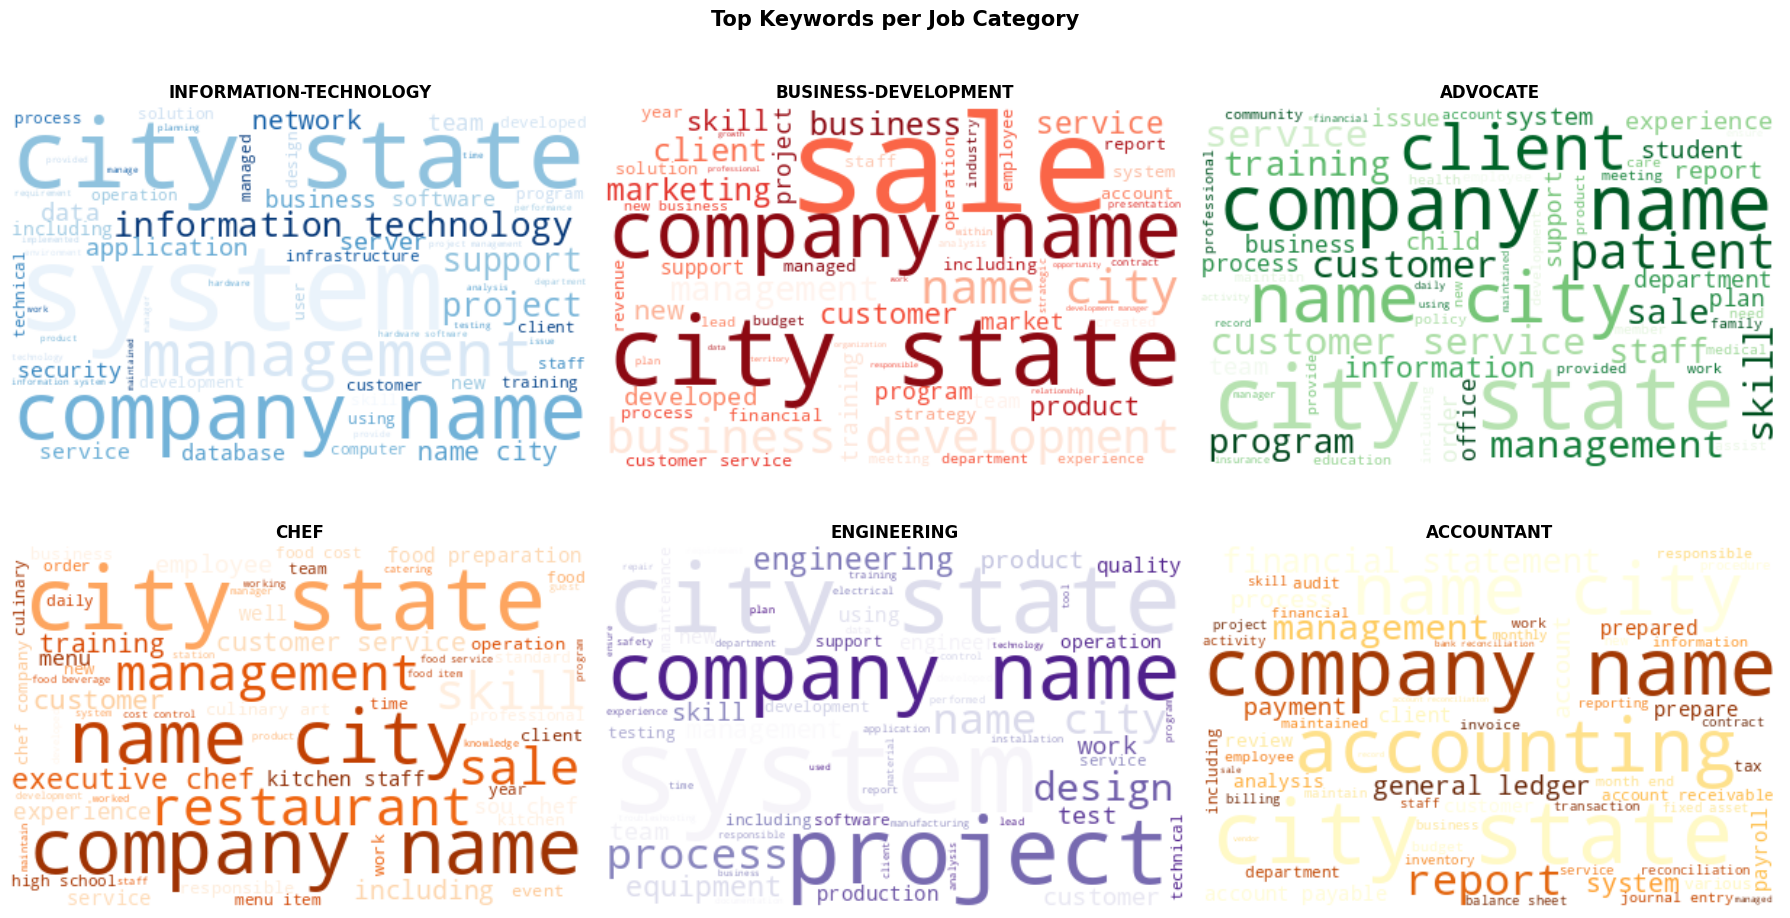

In [14]:
if WC:
    top_cats   = df['Category'].value_counts().head(6).index
    fig, axes  = plt.subplots(2, 3, figsize=(18, 10))
    axes       = axes.ravel()
    cmaps      = ['Blues','Reds','Greens',
                  'Oranges','Purples','YlOrBr']

    for ax, cat, cmap in zip(axes, top_cats, cmaps):
        corpus = ' '.join(
            df[df['Category']==cat]['cleaned'].tolist())
        wc = WordCloud(width=400, height=250,
                       background_color='white',
                       colormap=cmap,
                       max_words=60).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{cat}', fontsize=12, fontweight='bold')

    plt.suptitle('Top Keywords per Job Category',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [15]:
print(" Building TF-IDF Features...")

tfidf = TfidfVectorizer(
    max_features = 15000,
    ngram_range  = (1, 2),
    min_df       = 2,
    sublinear_tf = True
)

tfidf_matrix = tfidf.fit_transform(df['cleaned'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Sample features    : {tfidf.get_feature_names_out()[:20]}")

 Building TF-IDF Features...
TF-IDF matrix shape: (2484, 15000)
Sample features    : ['aa' 'aaa' 'abc' 'ability' 'ability analyze' 'ability build'
 'ability communicate' 'ability develop' 'ability effectively'
 'ability establish' 'ability handle' 'ability interact' 'ability lead'
 'ability learn' 'ability maintain' 'ability manage' 'ability multi'
 'ability multitask' 'ability organize' 'ability perform']


In [16]:
print(" Training Word2Vec on resumes...")

w2v_corpus = [text.split() for text in df['cleaned']]

w2v_model = Word2Vec(
    sentences   = w2v_corpus,
    vector_size = 100,
    window      = 5,
    min_count   = 2,
    workers     = 4,
    epochs      = 20
)
print(f" Word2Vec trained! Vocab: {len(w2v_model.wv)}")

# Similarity demo
demo_words = ['python','management','communication','data']
print("\nWord similarities:")
for word in demo_words:
    try:
        sim = w2v_model.wv.most_similar(word, topn=3)
        print(f"  '{word}' → {[s[0] for s in sim]}")
    except:
        pass

def doc_vector(text, model, size=100):
    """Average Word2Vec for a document."""
    words = text.split()
    vecs  = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

df['w2v_vec'] = df['cleaned'].apply(
    lambda x: doc_vector(x, w2v_model))

print(" Document vectors computed!")

 Training Word2Vec on resumes...
 Word2Vec trained! Vocab: 19545

Word similarities:
  'python' → ['perl', 'scripting', 'pspice']
  'management' → ['budgeting', 'leadership', 'administration']
  'communication' → ['communicator', 'resentation', 'interpersonal']
  'data' → ['database', 'journal', 'statistical']
 Document vectors computed!


In [17]:
print(" Computing Sentence Transformer Embeddings...")
print("   Model: all-MiniLM-L6-v2")

st_model   = SentenceTransformer('all-MiniLM-L6-v2')

# Use first 500 chars for speed
short_text = df['cleaned'].str[:500].tolist()

st_embeddings = st_model.encode(
    short_text,
    batch_size        = 64,
    show_progress_bar = True,
    convert_to_numpy  = True
)

df['st_vec'] = list(st_embeddings)

print(f" ST embeddings shape: {st_embeddings.shape}")

 Computing Sentence Transformer Embeddings...
   Model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/39 [00:00<?, ?it/s]

 ST embeddings shape: (2484, 384)


In [18]:
print("Computing BERT Embeddings (CLS token)...")

device         = torch.device('cuda' if torch.cuda.is_available()
                              else 'cpu')
print(f"   Device: {device}")

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_encoder   = BertModel.from_pretrained('bert-base-uncased')
bert_encoder    = bert_encoder.to(device)
bert_encoder.eval()

def get_bert_embedding(text, max_len=64):
    """Get BERT [CLS] token embedding."""
    enc = bert_tokenizer(
        str(text)[:200],
        max_length     = max_len,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = bert_encoder(**enc)
    return out.last_hidden_state[:, 0, :].cpu().numpy()[0]

# Compute for all resumes
print("Computing BERT embeddings (this may take a few minutes)...")
bert_embs = []
batch_sz  = 32
texts     = df['cleaned'].str[:200].tolist()

for i in range(0, len(texts), batch_sz):
    batch  = texts[i:i+batch_sz]
    batch_emb = [get_bert_embedding(t) for t in batch]
    bert_embs.extend(batch_emb)
    if (i // batch_sz) % 10 == 0:
        print(f"  Processed {min(i+batch_sz, len(texts))}"
              f"/{len(texts)}")

df['bert_vec'] = bert_embs
print(f" BERT embeddings done! Shape: {np.array(bert_embs).shape}")

Computing BERT Embeddings (CLS token)...
   Device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing BERT embeddings (this may take a few minutes)...
  Processed 32/2484
  Processed 352/2484
  Processed 672/2484
  Processed 992/2484
  Processed 1312/2484
  Processed 1632/2484
  Processed 1952/2484
  Processed 2272/2484
 BERT embeddings done! Shape: (2484, 768)


In [19]:
print(" RESUME SIMILARITY SCORING")

def resume_similarity(resume1_idx, resume2_idx, method='st'):
    """Compute cosine similarity between two resumes."""
    if method == 'tfidf':
        v1 = tfidf_matrix[resume1_idx]
        v2 = tfidf_matrix[resume2_idx]
        sim = cosine_similarity(v1, v2)[0][0]

    elif method == 'w2v':
        v1  = df['w2v_vec'].iloc[resume1_idx].reshape(1,-1)
        v2  = df['w2v_vec'].iloc[resume2_idx].reshape(1,-1)
        sim = cosine_similarity(v1, v2)[0][0]

    elif method == 'st':
        v1  = df['st_vec'].iloc[resume1_idx].reshape(1,-1)
        v2  = df['st_vec'].iloc[resume2_idx].reshape(1,-1)
        sim = cosine_similarity(v1, v2)[0][0]

    elif method == 'bert':
        v1  = np.array(df['bert_vec'].iloc[resume1_idx]).reshape(1,-1)
        v2  = np.array(df['bert_vec'].iloc[resume2_idx]).reshape(1,-1)
        sim = cosine_similarity(v1, v2)[0][0]

    return sim

# Demo: Compare pairs
print("\n Similarity between resumes (same category):")
same_cat = df[df['Category']=='Data Science'].index[:3].tolist()
for i in range(len(same_cat)):
    for j in range(i+1, len(same_cat)):
        for method in ['tfidf','w2v','st','bert']:
            s = resume_similarity(same_cat[i], same_cat[j], method)
            print(f"  [{method.upper():<5}] "
                  f"Resume {same_cat[i]} vs {same_cat[j]}: {s:.4f}")
        print()

 RESUME SIMILARITY SCORING

 Similarity between resumes (same category):


In [20]:
JOB_DB = [
    {
        'job_id'     : 1,
        'title'      : 'Data Scientist',
        'category'   : 'Data Science',
        'description': """We are looking for a Data Scientist with strong
        Python skills, experience in machine learning, deep learning,
        TensorFlow, PyTorch, pandas, numpy, scikit-learn. Knowledge of
        SQL, data visualization, tableau, power bi is a plus.
        Experience with NLP, computer vision preferred. PhD or MS
        in Computer Science, Statistics or related field."""
    },
    {
        'job_id'     : 2,
        'title'      : 'Software Engineer',
        'category'   : 'Java Developer',
        'description': """Seeking Software Engineer with expertise in
        Java, Spring Boot, microservices, REST APIs, SQL, git.
        Experience with Docker, Kubernetes, AWS, CI/CD pipelines.
        Knowledge of agile methodology, scrum. Strong problem solving
        and communication skills required. 3+ years experience."""
    },
    {
        'job_id'     : 3,
        'title'      : 'Web Developer',
        'category'   : 'Web Designing',
        'description': """Full Stack Web Developer needed with skills in
        HTML, CSS, JavaScript, React, Node.js, REST APIs.
        Experience with SQL, MongoDB, git, responsive design.
        Knowledge of Bootstrap, jQuery, Angular is plus.
        Strong portfolio of web projects required."""
    },
    {
        'job_id'     : 4,
        'title'      : 'ML Engineer',
        'category'   : 'Machine Learning',
        'description': """Machine Learning Engineer with expertise in
        Python, TensorFlow, PyTorch, deep learning, neural networks.
        Experience with computer vision, NLP, BERT, transformers.
        Strong knowledge of MLOps, Docker, AWS, model deployment.
        Research publications in ML/AI preferred."""
    },
    {
        'job_id'     : 5,
        'title'      : 'DevOps Engineer',
        'category'   : 'DevOps Engineer',
        'description': """DevOps Engineer with expertise in AWS, Azure,
        Docker, Kubernetes, Jenkins, CI/CD, Terraform, Ansible.
        Strong Linux, bash scripting, git, monitoring skills.
        Experience with microservices architecture. Agile mindset.
        AWS/Azure certification preferred."""
    },
    {
        'job_id'     : 6,
        'title'      : 'HR Manager',
        'category'   : 'HR',
        'description': """HR Manager with experience in recruitment,
        talent acquisition, performance management, employee relations.
        Knowledge of HR policies, labor laws, payroll, HRIS systems.
        Strong communication, leadership, conflict resolution skills.
        MBA in Human Resources preferred."""
    },
    {
        'job_id'     : 7,
        'title'      : 'Business Analyst',
        'category'   : 'Business Analyst',
        'description': """Business Analyst with strong analytical skills,
        SQL, Excel, Power BI, Tableau, data analysis experience.
        Knowledge of agile, scrum, requirement gathering, process mapping.
        Experience with stakeholder management, documentation.
        MBA or relevant certification preferred."""
    },
    {
        'job_id'     : 8,
        'title'      : 'Network Engineer',
        'category'   : 'Network Security Engineer',
        'description': """Network Security Engineer with expertise in
        network protocols, firewalls, VPN, intrusion detection systems.
        Experience with Cisco, security tools, SIEM, penetration testing.
        Knowledge of cybersecurity frameworks, compliance.
        CCNA, CISSP certification preferred."""
    },
]

job_df = pd.DataFrame(JOB_DB)
print("Job Database:")
print(job_df[['job_id','title','category']].to_string())

Job Database:
   job_id              title                   category
0       1     Data Scientist               Data Science
1       2  Software Engineer             Java Developer
2       3      Web Developer              Web Designing
3       4        ML Engineer           Machine Learning
4       5    DevOps Engineer            DevOps Engineer
5       6         HR Manager                         HR
6       7   Business Analyst           Business Analyst
7       8   Network Engineer  Network Security Engineer


In [21]:
# Precompute job embeddings (ST + BERT)
print(" Computing job embeddings...")

job_cleaned = [preprocess(j['description']) for j in JOB_DB]

# TF-IDF for jobs (using same fitted vectorizer)
job_tfidf   = tfidf.transform(job_cleaned)

# Sentence Transformer for jobs
job_st_emb  = st_model.encode(
    job_cleaned, batch_size=8,
    show_progress_bar=False)

# BERT for jobs
job_bert_emb = np.array(
    [get_bert_embedding(t) for t in job_cleaned])

print(" Job embeddings ready!")

def recommend_jobs(resume_text, top_n=5, method='st'):
    """
    Recommend top N jobs for a given resume.
    method: 'tfidf' | 'w2v' | 'st' | 'bert'
    """
    cleaned = preprocess(resume_text)

    if method == 'tfidf':
        r_vec   = tfidf.transform([cleaned])
        sims    = cosine_similarity(r_vec, job_tfidf)[0]

    elif method == 'w2v':
        r_vec   = doc_vector(cleaned, w2v_model).reshape(1,-1)
        j_vecs  = np.array([doc_vector(t, w2v_model)
                             for t in job_cleaned])
        sims    = cosine_similarity(r_vec, j_vecs)[0]

    elif method == 'st':
        r_vec   = st_model.encode([cleaned])
        sims    = cosine_similarity(r_vec, job_st_emb)[0]

    elif method == 'bert':
        r_vec   = get_bert_embedding(cleaned).reshape(1,-1)
        sims    = cosine_similarity(r_vec, job_bert_emb)[0]

    top_idx = sims.argsort()[-top_n:][::-1]
    recs    = []
    for idx in top_idx:
        recs.append({
            'rank'       : len(recs)+1,
            'job_id'     : JOB_DB[idx]['job_id'],
            'title'      : JOB_DB[idx]['title'],
            'category'   : JOB_DB[idx]['category'],
            'similarity' : round(float(sims[idx]), 4)
        })
    return pd.DataFrame(recs)

 Computing job embeddings...
 Job embeddings ready!


In [22]:
print(" JOB RECOMMENDATION DEMO")

# Test resume 1 — Data Science candidate
test_resume_1 = """
Experienced Data Scientist with 5 years of expertise in machine learning,
deep learning, Python, TensorFlow, PyTorch, scikit-learn, pandas, numpy.
Strong background in NLP, computer vision, BERT, transformers.
PhD in Computer Science. Published 10 papers in top ML conferences.
Experience with AWS, Docker, SQL, data visualization, Tableau.
"""

# Test resume 2 — Web Developer candidate
test_resume_2 = """
Full Stack Web Developer with 3 years experience in HTML, CSS,
JavaScript, React, Node.js, REST APIs, MongoDB, SQL, git.
Built 20+ responsive websites and web applications.
Experience with Bootstrap, jQuery, Angular, Django, Flask.
Strong knowledge of UI/UX design principles.
"""

# Test resume 3 — DevOps candidate
test_resume_3 = """
DevOps Engineer with expertise in AWS, Azure, Docker, Kubernetes,
Jenkins, CI/CD pipelines, Terraform, Ansible, Linux administration.
AWS Certified Solutions Architect. Experience with microservices,
monitoring tools, bash scripting, git, agile methodology.
"""

test_resumes = [
    ("Data Scientist Candidate",  test_resume_1),
    ("Web Developer Candidate",   test_resume_2),
    ("DevOps Engineer Candidate", test_resume_3),
]

for name, resume in test_resumes:
    print(f"\n{'─'*55}")
    print(f" {name}")
    print(f"{'─'*55}")
    for method in ['tfidf','w2v','st','bert']:
        recs = recommend_jobs(resume, top_n=3, method=method)
        print(f"\n   [{method.upper():<5}] Top 3 Recommendations:")
        for _, row in recs.iterrows():
            bar = '█' * int(row['similarity']*20)
            print(f"    {row['rank']}. {row['title']:<20}"
                  f"  Sim={row['similarity']:.4f}  {bar}")

 JOB RECOMMENDATION DEMO

───────────────────────────────────────────────────────
 Data Scientist Candidate
───────────────────────────────────────────────────────

   [TFIDF] Top 3 Recommendations:
    1. Data Scientist        Sim=0.7264  ██████████████
    2. ML Engineer           Sim=0.4964  █████████
    3. DevOps Engineer       Sim=0.1268  ██

   [W2V  ] Top 3 Recommendations:
    1. Data Scientist        Sim=0.9411  ██████████████████
    2. ML Engineer           Sim=0.8393  ████████████████
    3. Software Engineer     Sim=0.7842  ███████████████

   [ST   ] Top 3 Recommendations:
    1. Data Scientist        Sim=0.8377  ████████████████
    2. ML Engineer           Sim=0.7960  ███████████████
    3. Software Engineer     Sim=0.3380  ██████

   [BERT ] Top 3 Recommendations:
    1. HR Manager            Sim=0.8979  █████████████████
    2. ML Engineer           Sim=0.8955  █████████████████
    3. Business Analyst      Sim=0.8898  █████████████████

─────────────────────────────

Computing Resume Similarity Matrix...


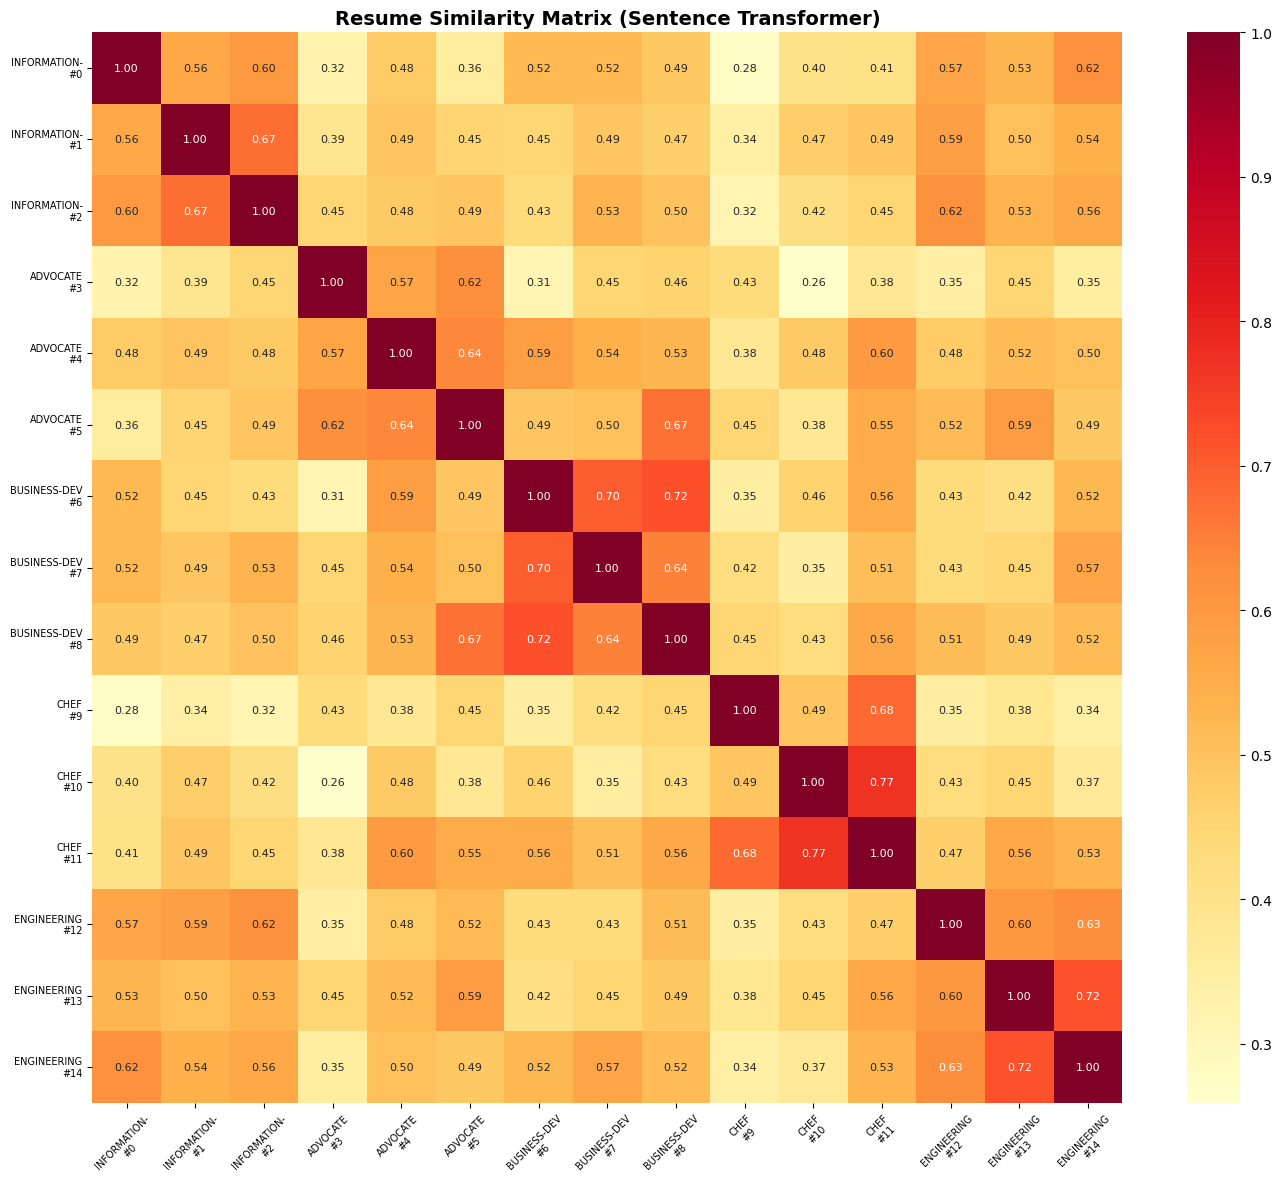

In [23]:
print("Computing Resume Similarity Matrix...")

# Sample 5 resumes per category (top 5 categories)
top5_cats = df['Category'].value_counts().head(5).index.tolist()
sample_df = df[df['Category'].isin(top5_cats)]\
              .groupby('Category')\
              .head(3)\
              .reset_index(drop=True)

sample_st  = np.array(sample_df['st_vec'].tolist())
sim_matrix = cosine_similarity(sample_st)

labels = [f"{row['Category'][:12]}\n#{i}"
          for i, (_, row) in enumerate(sample_df.iterrows())]

plt.figure(figsize=(14, 12))
sns.heatmap(sim_matrix,
            annot   = True,
            fmt     = '.2f',
            cmap    = 'YlOrRd',
            xticklabels = labels,
            yticklabels = labels,
            annot_kws   = {'size': 8})
plt.title('Resume Similarity Matrix (Sentence Transformer)',
          fontsize=14, fontweight='bold')
plt.xticks(fontsize=7, rotation=45)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

In [24]:
print(" CANDIDATE RANKING SYSTEM")

def rank_candidates(job_description, df_resumes,
                    top_n=10, method='st'):
    """
    Rank all candidates for a given job description.
    Returns top N candidates with scores.
    """
    jd_cleaned = preprocess(job_description)

    if method == 'tfidf':
        jd_vec   = tfidf.transform([jd_cleaned])
        sims     = cosine_similarity(jd_vec, tfidf_matrix)[0]

    elif method == 'w2v':
        jd_vec   = doc_vector(jd_cleaned, w2v_model).reshape(1,-1)
        r_vecs   = np.array(df_resumes['w2v_vec'].tolist())
        sims     = cosine_similarity(jd_vec, r_vecs)[0]

    elif method == 'st':
        jd_vec   = st_model.encode([jd_cleaned])
        r_vecs   = np.array(df_resumes['st_vec'].tolist())
        sims     = cosine_similarity(jd_vec, r_vecs)[0]

    elif method == 'bert':
        jd_vec   = get_bert_embedding(jd_cleaned).reshape(1,-1)
        r_vecs   = np.array(df_resumes['bert_vec'].tolist())
        sims     = cosine_similarity(jd_vec, r_vecs)[0]

    top_idx  = sims.argsort()[-top_n:][::-1]
    ranked   = []
    for rank, idx in enumerate(top_idx, 1):
        ranked.append({
            'Rank'       : rank,
            'Category'   : df_resumes['Category'].iloc[idx],
            'Similarity' : round(float(sims[idx]), 4),
            'Skills'     : df_resumes['skill_count'].iloc[idx],
            'Word Count' : df_resumes['word_count'].iloc[idx],
            'Resume_idx' : idx
        })
    return pd.DataFrame(ranked)

# Rank for Data Scientist JD
jd_ds = JOB_DB[0]['description']

print("\n Ranking candidates for: DATA SCIENTIST role")

for method in ['tfidf','st','bert']:
    ranked_df = rank_candidates(jd_ds, df, top_n=5, method=method)
    print(f"\n[{method.upper()}] Top 5 Candidates:")
    print(ranked_df[['Rank','Category','Similarity',
                      'Skills','Word Count']].to_string(index=False))

 CANDIDATE RANKING SYSTEM

 Ranking candidates for: DATA SCIENTIST role

[TFIDF] Top 5 Candidates:
 Rank    Category  Similarity  Skills  Word Count
    1 ENGINEERING      0.1976      12         915
    2  AUTOMOBILE      0.1837      16         462
    3  CONSULTANT      0.1764      16         749
    4 AGRICULTURE      0.1600      28        1101
    5     BANKING      0.1435      10         406

[ST] Top 5 Candidates:
 Rank    Category  Similarity  Skills  Word Count
    1  AUTOMOBILE      0.6496      16         462
    2 ENGINEERING      0.5536      12         915
    3 AGRICULTURE      0.5394      13        1196
    4 ENGINEERING      0.5392      14        1209
    5     BANKING      0.5205      10         406

[BERT] Top 5 Candidates:
 Rank               Category  Similarity  Skills  Word Count
    1            ENGINEERING      0.9701      14        1209
    2             CONSULTANT      0.9497      12        1051
    3             ACCOUNTANT      0.9496       4         718
    4  

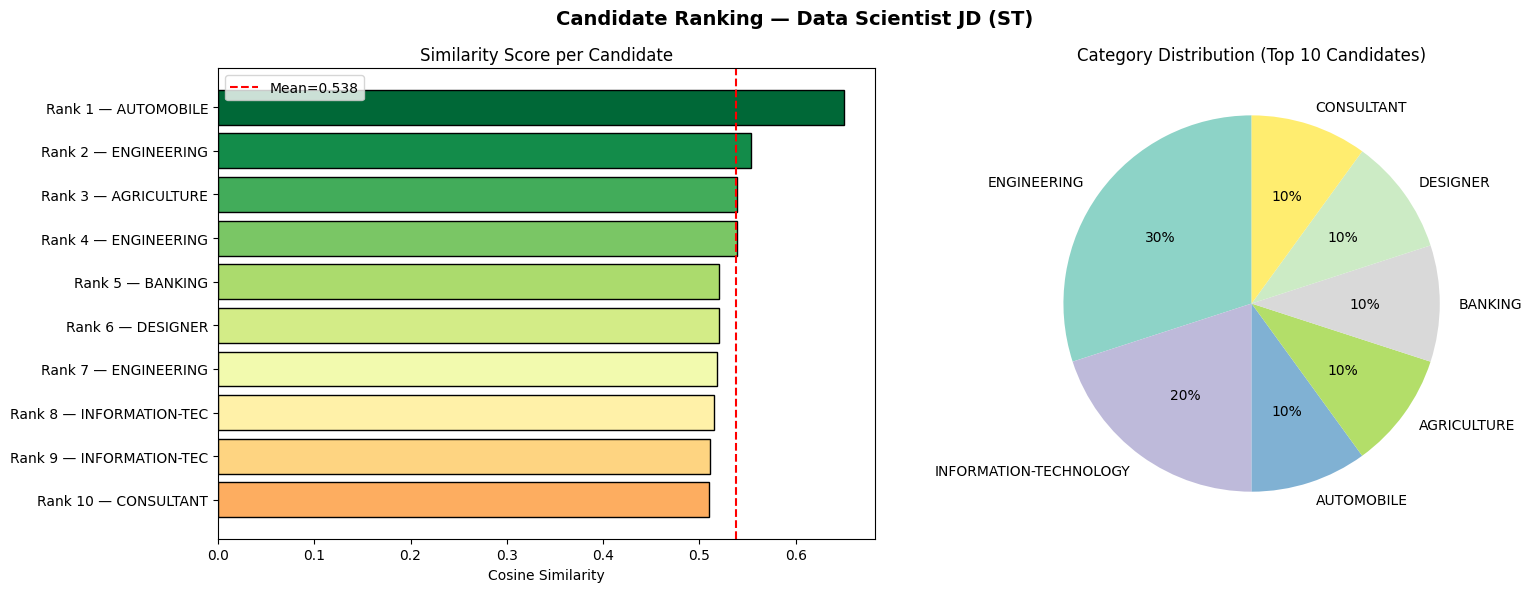

In [25]:
# Visualize ranking for Data Scientist JD (ST method)
ranked_st = rank_candidates(jd_ds, df, top_n=10, method='st')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Candidate Ranking — Data Scientist JD (ST)',
             fontsize=14, fontweight='bold')

# Similarity scores
colors = plt.cm.RdYlGn(
    np.linspace(0.3, 1.0, len(ranked_st)))[::-1]

axes[0].barh(
    [f"Rank {r} — {c[:15]}"
     for r, c in zip(ranked_st['Rank'], ranked_st['Category'])],
    ranked_st['Similarity'],
    color=colors, edgecolor='black')
axes[0].set_title('Similarity Score per Candidate')
axes[0].set_xlabel('Cosine Similarity')
axes[0].invert_yaxis()
axes[0].axvline(ranked_st['Similarity'].mean(),
                color='red', linestyle='--',
                label=f"Mean={ranked_st['Similarity'].mean():.3f}")
axes[0].legend()

# Category distribution of ranked candidates
cat_dist = ranked_st['Category'].value_counts()
axes[1].pie(cat_dist.values,
            labels   = cat_dist.index,
            autopct  = '%1.0f%%',
            startangle=90,
            colors   = plt.cm.Set3(
                np.linspace(0,1,len(cat_dist))))
axes[1].set_title('Category Distribution (Top 10 Candidates)')

plt.tight_layout()
plt.show()

In [26]:
print(" RESUME CLASSIFICATION")

# Prepare data
le   = LabelEncoder()
y    = le.fit_transform(df['Category'])
NUM_CLASSES = len(le.classes_)

# TF-IDF features
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    tfidf_matrix, y, test_size=0.2, random_state=42, stratify=y)

# ST features
st_arr = np.array(df['st_vec'].tolist())
X_tr_st, X_te_st, y_tr_st, y_te_st = train_test_split(
    st_arr, y, test_size=0.2, random_state=42, stratify=y)

clf_results = {}

def eval_clf(name, model, X_tr, X_te, y_tr, y_te, feat=''):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)
    label  = f"{name} ({feat})" if feat else name
    clf_results[label] = {'Accuracy': round(acc, 4)}

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(classification_report(y_te, y_pred,
          target_names=le.classes_, zero_division=0))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                annot_kws={'size': 6})
    plt.title(f'{name} — Confusion Matrix',
              fontsize=13, fontweight='bold')
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0,  fontsize=7)
    plt.tight_layout(); plt.show()
    return acc

 RESUME CLASSIFICATION



  Logistic Regression (TF-IDF)
  Accuracy : 0.6459
                        precision    recall  f1-score   support

            ACCOUNTANT       0.67      0.83      0.74        24
              ADVOCATE       0.39      0.50      0.44        24
           AGRICULTURE       1.00      0.23      0.38        13
               APPAREL       0.75      0.16      0.26        19
                  ARTS       0.57      0.19      0.29        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.85      0.71      0.77        24
               BANKING       0.89      0.70      0.78        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.54      0.88      0.67        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.74      0.77      0.76        22
            CONSULTANT       0.62      0.22      0.32        23
              DESIGNER       0.80      0.76      0.

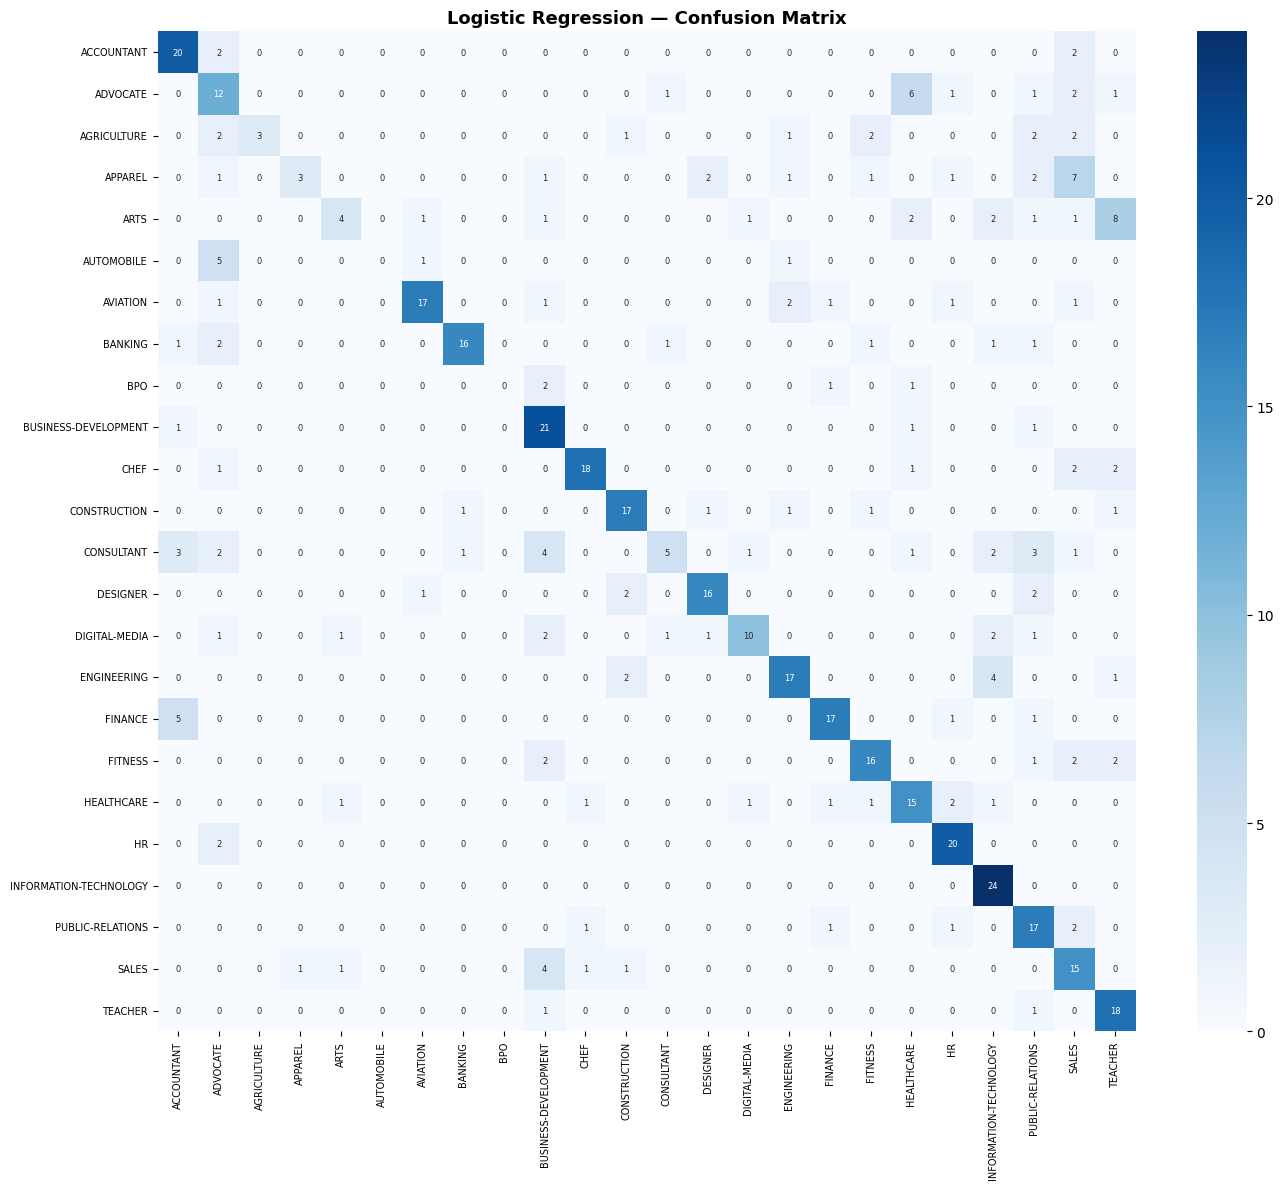

0.6458752515090543

In [27]:
lr_tfidf = LogisticRegression(
    max_iter    = 1000,
    C           = 1.0,
    solver      = 'lbfgs',
    multi_class = 'multinomial',
    random_state= 42
)
eval_clf('Logistic Regression', lr_tfidf,
         X_train_tfidf, X_test_tfidf,
         y_train, y_test, 'TF-IDF')


  SVM (TF-IDF)
  Accuracy : 0.7264
                        precision    recall  f1-score   support

            ACCOUNTANT       0.80      0.83      0.82        24
              ADVOCATE       0.48      0.67      0.56        24
           AGRICULTURE       0.90      0.69      0.78        13
               APPAREL       0.67      0.32      0.43        19
                  ARTS       0.62      0.48      0.54        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.86      0.79      0.83        24
               BANKING       0.80      0.70      0.74        23
                   BPO       0.33      0.25      0.29         4
  BUSINESS-DEVELOPMENT       0.68      0.88      0.76        24
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.75      0.82      0.78        22
            CONSULTANT       0.71      0.52      0.60        23
              DESIGNER       0.90      0.90      0.90        21
   

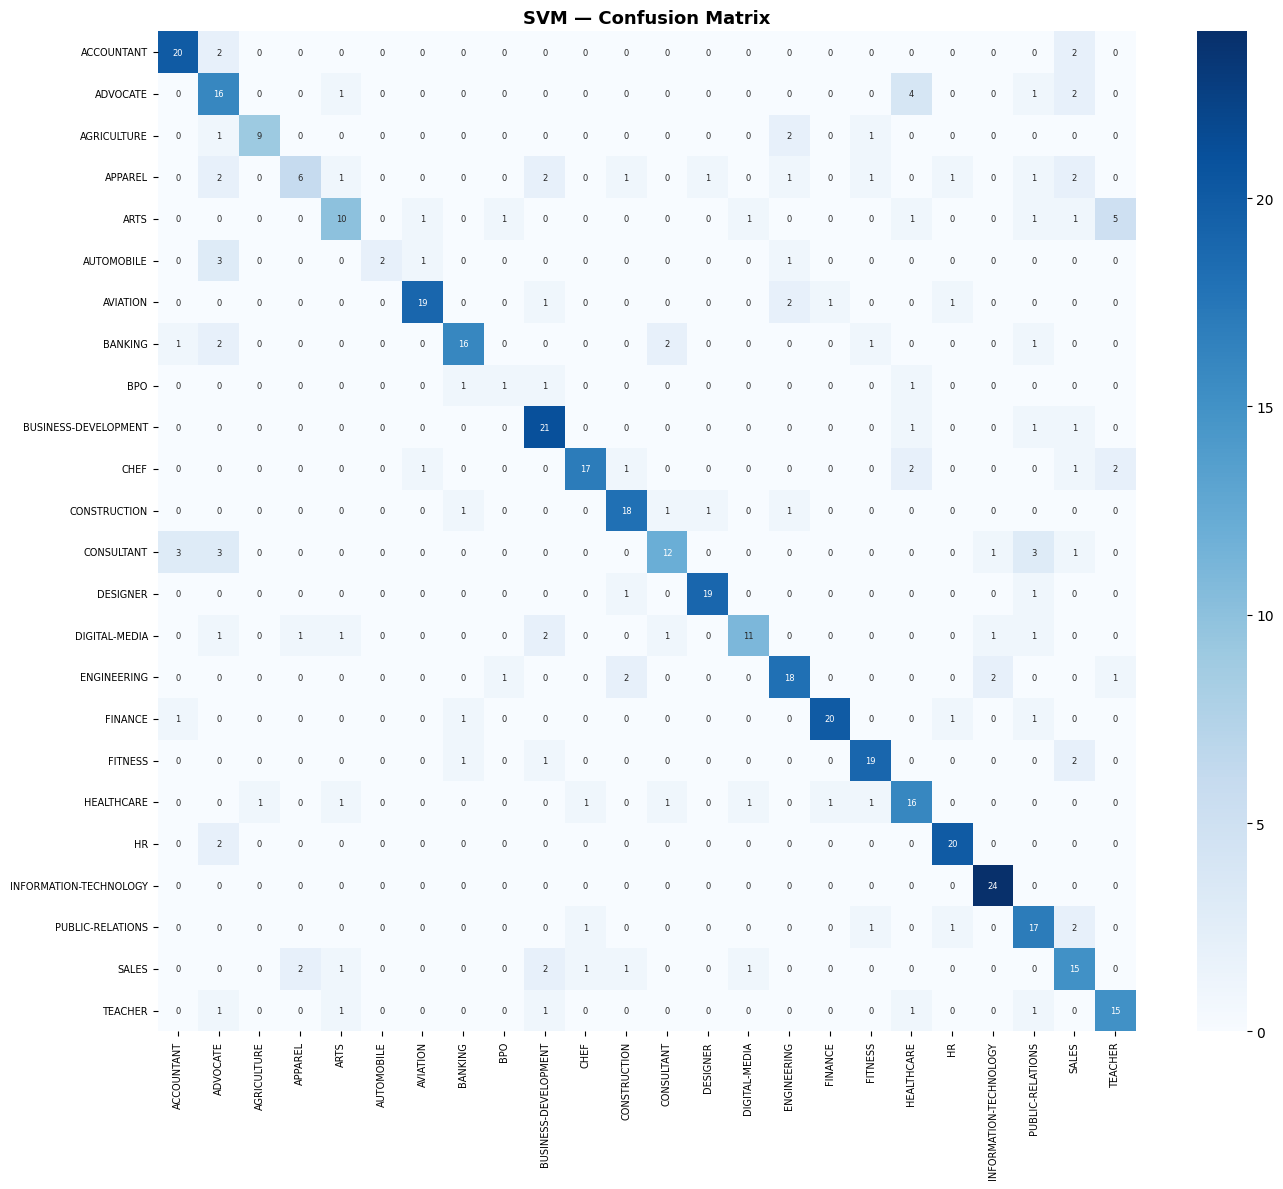

0.7263581488933601

In [28]:
svm_base = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm      = CalibratedClassifierCV(svm_base, cv=3)
eval_clf('SVM', svm,
         X_train_tfidf, X_test_tfidf,
         y_train, y_test, 'TF-IDF')


  Random Forest (ST Embeddings)
  Accuracy : 0.6761
                        precision    recall  f1-score   support

            ACCOUNTANT       0.79      0.96      0.87        24
              ADVOCATE       0.55      0.75      0.63        24
           AGRICULTURE       1.00      0.08      0.14        13
               APPAREL       0.40      0.11      0.17        19
                  ARTS       0.33      0.14      0.20        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.60      0.62      0.61        24
               BANKING       0.56      0.39      0.46        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.75      1.00      0.86        24
                  CHEF       0.95      0.83      0.89        24
          CONSTRUCTION       0.81      0.77      0.79        22
            CONSULTANT       0.72      0.78      0.75        23
              DESIGNER       0.76      0.90      0

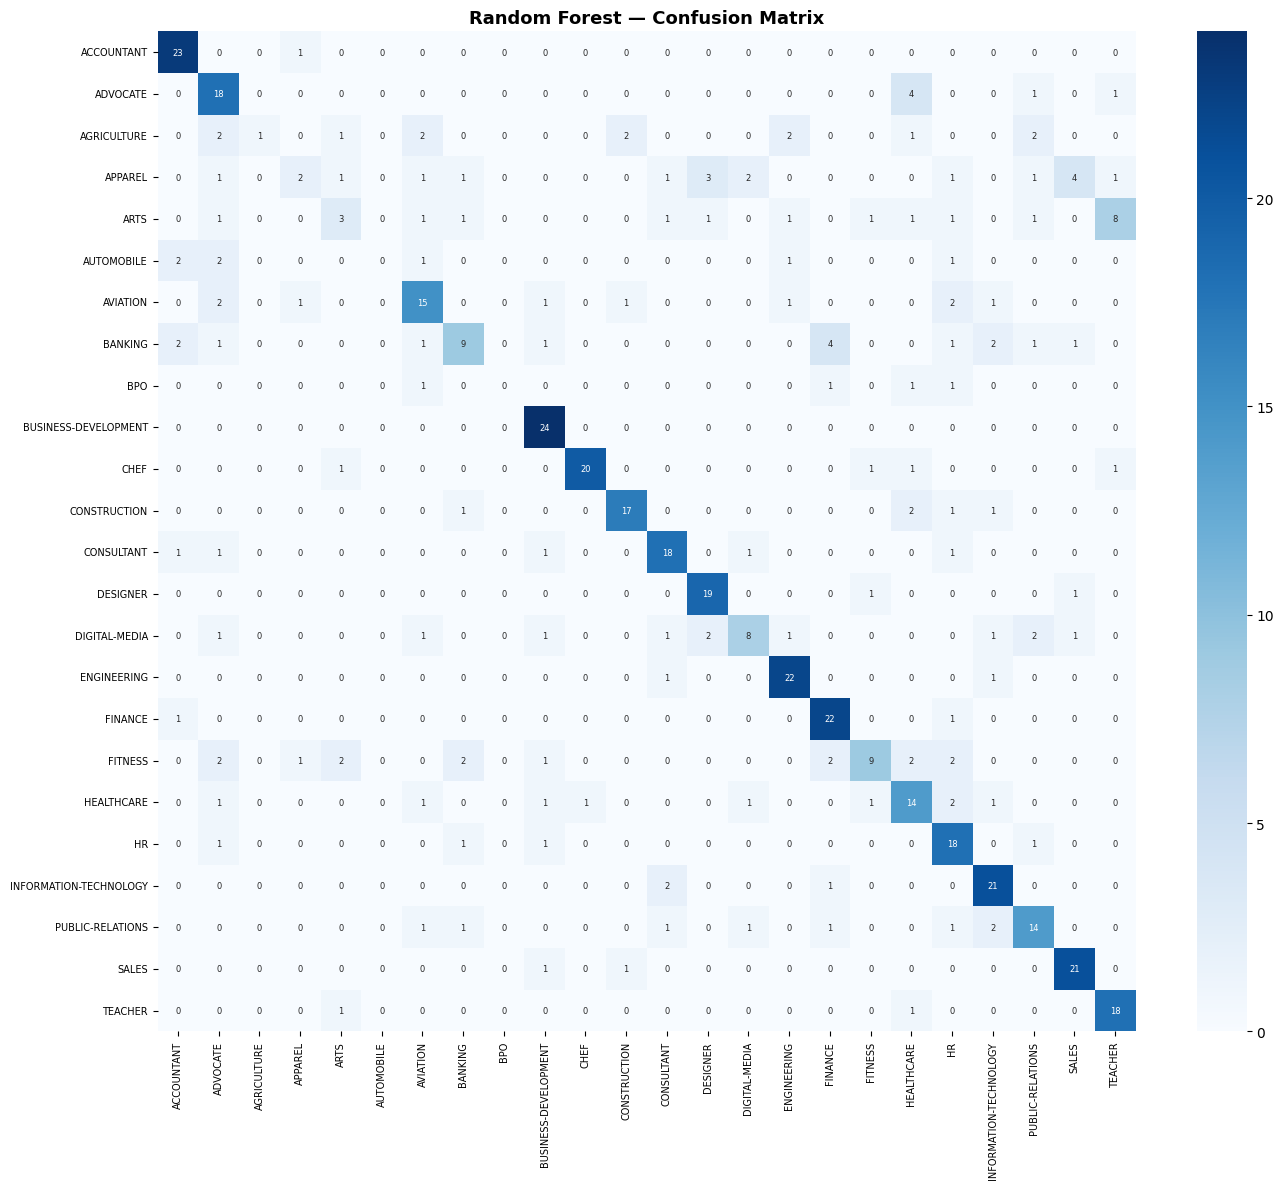

0.676056338028169

In [29]:
rf_st = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1)
eval_clf('Random Forest', rf_st,
         X_tr_st, X_te_st,
         y_tr_st, y_te_st, 'ST Embeddings')


  Logistic Regression (ST Embeddings)
  Accuracy : 0.7264
                        precision    recall  f1-score   support

            ACCOUNTANT       0.82      0.96      0.88        24
              ADVOCATE       0.65      0.71      0.68        24
           AGRICULTURE       1.00      0.23      0.38        13
               APPAREL       0.55      0.32      0.40        19
                  ARTS       0.55      0.29      0.38        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.74      0.71      0.72        24
               BANKING       0.58      0.48      0.52        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.77      1.00      0.87        24
                  CHEF       0.95      0.83      0.89        24
          CONSTRUCTION       0.79      0.86      0.83        22
            CONSULTANT       0.79      0.83      0.81        23
              DESIGNER       0.86      0.90 

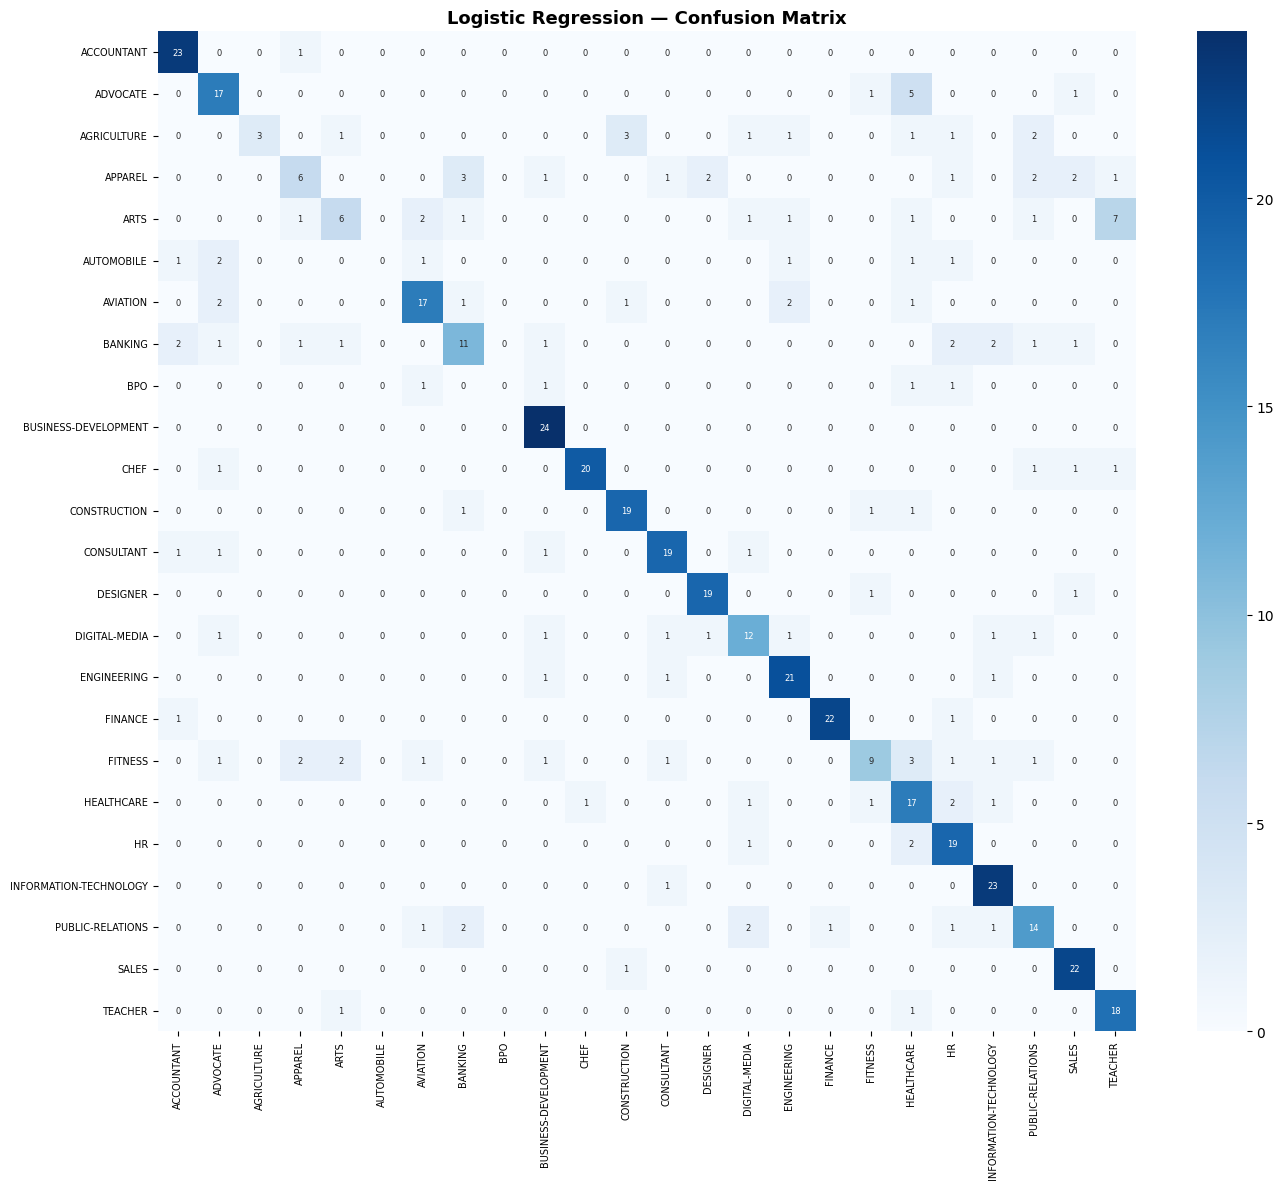

0.7263581488933601

In [30]:
lr_st_clf = LogisticRegression(
    max_iter=1000, multi_class='multinomial', random_state=42)
eval_clf('Logistic Regression', lr_st_clf,
         X_tr_st, X_te_st,
         y_tr_st, y_te_st, 'ST Embeddings')

DNN Resume Classifier (ST Embeddings)...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 374,744 (1.43 MB)

 Trainable params: 372,952 (1.42 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.1622 - loss: 3.1077 - val_accuracy: 0.4372 - val_loss: 2.3403
Epoch 2/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4256 - loss: 2.0879 - val_accuracy: 0.5829 - val_loss: 1.7315
Epoch 3/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5302 - loss: 1.7247 - val_accuracy: 0.6181 - val_loss: 1.5272
Epoch 4/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6230 - loss: 1.4376 - val_accuracy: 0.6583 - val_loss: 1.3888
Epoch 5/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6415 - loss: 1.3135 - val_accuracy: 0.6432 - val_loss: 1.3675
Epoch 6/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6941 - loss: 1.1472 - val_accuracy: 0.6583 - val_loss: 1.3910
Epoch 7/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7181 - loss: 1.0215 - val_accuracy: 0.6784 - val_loss: 1.3660
Epoch 8/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7360 - loss: 0.9642 - val_accuracy: 0.6633 - val_los

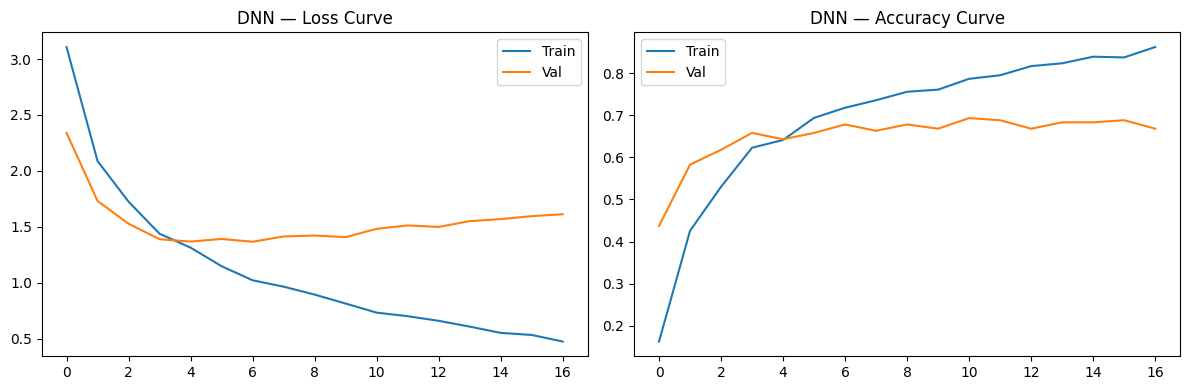


  DNN Accuracy : 0.7042
                        precision    recall  f1-score   support

            ACCOUNTANT       0.85      0.92      0.88        24
              ADVOCATE       0.67      0.75      0.71        24
           AGRICULTURE       0.50      0.15      0.24        13
               APPAREL       0.26      0.37      0.30        19
                  ARTS       0.47      0.38      0.42        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.61      0.71      0.65        24
               BANKING       0.48      0.43      0.45        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.92      0.92      0.92        24
                  CHEF       0.95      0.83      0.89        24
          CONSTRUCTION       0.85      0.77      0.81        22
            CONSULTANT       0.83      0.87      0.85        23
              DESIGNER       0.95      0.95      0.95        21
         DIGIT

In [32]:
print("DNN Resume Classifier (ST Embeddings)...")

scaler_dnn = StandardScaler()
X_tr_dnn   = scaler_dnn.fit_transform(X_tr_st)
X_te_dnn   = scaler_dnn.transform(X_te_st)

y_tr_cat   = to_categorical(y_tr_st, NUM_CLASSES)
y_te_cat   = to_categorical(y_te_st, NUM_CLASSES)

# Val split
X_tr_dnn, X_val_dnn, y_tr_dnn_c, y_val_dnn_c = train_test_split(
    X_tr_dnn, y_tr_cat,
    test_size=0.1, random_state=42)

dnn_clf = Sequential([
    Dense(512, activation='relu',
          input_dim=X_tr_dnn.shape[1]),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.35),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
])

dnn_clf.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
dnn_clf.summary()

es = EarlyStopping(patience=10,
                   restore_best_weights=True, verbose=0)

h = dnn_clf.fit(
    X_tr_dnn, y_tr_dnn_c,
    validation_data = (X_val_dnn, y_val_dnn_c),
    epochs     = 80,
    batch_size = 32,
    callbacks  = [es],
    verbose    = 1
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h.history['loss'],     label='Train')
axes[0].plot(h.history['val_loss'], label='Val')
axes[0].set_title('DNN — Loss Curve')
axes[0].legend()
axes[1].plot(h.history['accuracy'],     label='Train')
axes[1].plot(h.history['val_accuracy'], label='Val')
axes[1].set_title('DNN — Accuracy Curve')
axes[1].legend()
plt.tight_layout(); plt.show()

# Evaluate DNN
dnn_prob = dnn_clf.predict(X_te_dnn, verbose=0)
dnn_pred = np.argmax(dnn_prob, axis=1)
dnn_acc  = accuracy_score(y_te_st, dnn_pred)
clf_results['DNN (ST Embeddings)'] = {'Accuracy': round(dnn_acc, 4)}

print(f"\n  DNN Accuracy : {dnn_acc:.4f}")
print(classification_report(y_te_st, dnn_pred,
      target_names=le.classes_, zero_division=0))

In [33]:
print("SEMANTIC SEARCH ENGINE")

def semantic_search(query, df_resumes, top_n=5,
                    method='st'):
    """Search resumes using semantic similarity."""
    q_clean = preprocess(query)

    if method == 'st':
        q_vec  = st_model.encode([q_clean])
        r_vecs = np.array(df_resumes['st_vec'].tolist())
        sims   = cosine_similarity(q_vec, r_vecs)[0]

    elif method == 'tfidf':
        q_vec  = tfidf.transform([q_clean])
        sims   = cosine_similarity(q_vec, tfidf_matrix)[0]

    elif method == 'bert':
        q_vec  = get_bert_embedding(q_clean).reshape(1,-1)
        r_vecs = np.array(df_resumes['bert_vec'].tolist())
        sims   = cosine_similarity(q_vec, r_vecs)[0]

    top_idx = sims.argsort()[-top_n:][::-1]
    results = []
    for rank, idx in enumerate(top_idx, 1):
        results.append({
            'Rank'      : rank,
            'Category'  : df_resumes['Category'].iloc[idx],
            'Similarity': round(float(sims[idx]), 4),
            'Preview'   : str(df_resumes['Resume_str']
                              .iloc[idx])[:100] + '...'
        })
    return pd.DataFrame(results)

# Semantic search queries
queries = [
    "Python machine learning deep learning NLP expert",
    "AWS DevOps Docker Kubernetes cloud engineer",
    "React JavaScript frontend web developer",
    "HR recruitment talent management people skills",
]

for query in queries:
    print(f"\n Query: '{query}'")
    res = semantic_search(query, df, top_n=3, method='st')
    for _, row in res.iterrows():
        print(f"  {row['Rank']}. [{row['Category']:<20}]"
              f"  Sim={row['Similarity']:.4f}")
        print(f"     {row['Preview'][:80]}")

SEMANTIC SEARCH ENGINE

 Query: 'Python machine learning deep learning NLP expert'
  1. [BANKING             ]  Sim=0.3573
              CORPORATE BANKING ASSISTANT, INTERN           Objective     Dynamic and
  2. [ENGINEERING         ]  Sim=0.3352
              ENGINEERING INTERN         Skills          C++, Python, MATLAB, Git, Ba
  3. [DIGITAL-MEDIA       ]  Sim=0.3270
              SOCIAL MEDIA CONTENT CREATOR       Summary     Communications expert wh

 Query: 'AWS DevOps Docker Kubernetes cloud engineer'
  1. [INFORMATION-TECHNOLOGY]  Sim=0.4540
              INFORMATION TECHNOLOGY AND AWS ADMIN INTERN           Experience      I
  2. [ADVOCATE            ]  Sim=0.3353
              LEVEL 2 CRITICAL PLATFORM SUPPORT ENGINEER       Career Overview    Ove
  3. [ENGINEERING         ]  Sim=0.3115
              SUPPORT ENGINEERING MANAGER         Summary     Successful and motivate

 Query: 'React JavaScript frontend web developer'
  1. [DESIGNER            ]  Sim=0.3248
             

In [34]:
print(" SKILL GAP ANALYSIS")

def skill_gap_analysis(resume_text, job_description):
    """
    Compare resume skills vs job requirements.
    Returns matched, missing, and score.
    """
    resume_skills = set()
    jd_skills     = set()

    for cat, skills in extract_skills(resume_text).items():
        resume_skills.update(skills)

    for cat, skills in extract_skills(job_description).items():
        jd_skills.update(skills)

    matched  = resume_skills & jd_skills
    missing  = jd_skills - resume_skills
    extra    = resume_skills - jd_skills
    score    = (len(matched) / len(jd_skills) * 100
                if jd_skills else 0)

    return {
        'matched'       : sorted(matched),
        'missing'       : sorted(missing),
        'extra'         : sorted(extra),
        'match_score'   : round(score, 1),
        'total_required': len(jd_skills),
        'total_matched' : len(matched),
    }

# Demo for each test resume vs relevant JD
demos = [
    ("Data Scientist Candidate",  test_resume_1, JOB_DB[0]['description']),
    ("Web Developer Candidate",   test_resume_2, JOB_DB[2]['description']),
    ("DevOps Engineer Candidate", test_resume_3, JOB_DB[4]['description']),
]

for name, resume, jd in demos:
    gap = skill_gap_analysis(resume, jd)
    print(f"\n {name}")
    print(f"   Matched Skills  ({gap['total_matched']}"
          f"/{gap['total_required']}): {gap['matched']}")
    print(f"   Missing Skills  : {gap['missing']}")
    print(f"   Extra Skills    : {gap['extra'][:5]}")
    print(f"   Match Score     : {gap['match_score']}%")

 SKILL GAP ANALYSIS

 Data Scientist Candidate
   Matched Skills  (13/14): ['computer vision', 'deep learning', 'machine learning', 'nlp', 'numpy', 'pandas', 'python', 'pytorch', 'r', 'scikit', 'sql', 'tableau', 'tensorflow']
   Missing Skills  : ['power bi']
   Extra Skills    : ['aws', 'bert', 'docker', 'transformers']
   Match Score     : 92.9%

 Web Developer Candidate
   Matched Skills  (14/14): ['angular', 'api', 'bootstrap', 'css', 'git', 'html', 'java', 'javascript', 'jquery', 'mongodb', 'node', 'r', 'react', 'sql']
   Missing Skills  : []
   Extra Skills    : ['django', 'flask']
   Match Score     : 100.0%

 DevOps Engineer Candidate
   Matched Skills  (13/13): ['agile', 'ansible', 'aws', 'azure', 'ci/cd', 'devops', 'docker', 'git', 'jenkins', 'kubernetes', 'linux', 'r', 'terraform']
   Missing Skills  : []
   Extra Skills    : []
   Match Score     : 100.0%


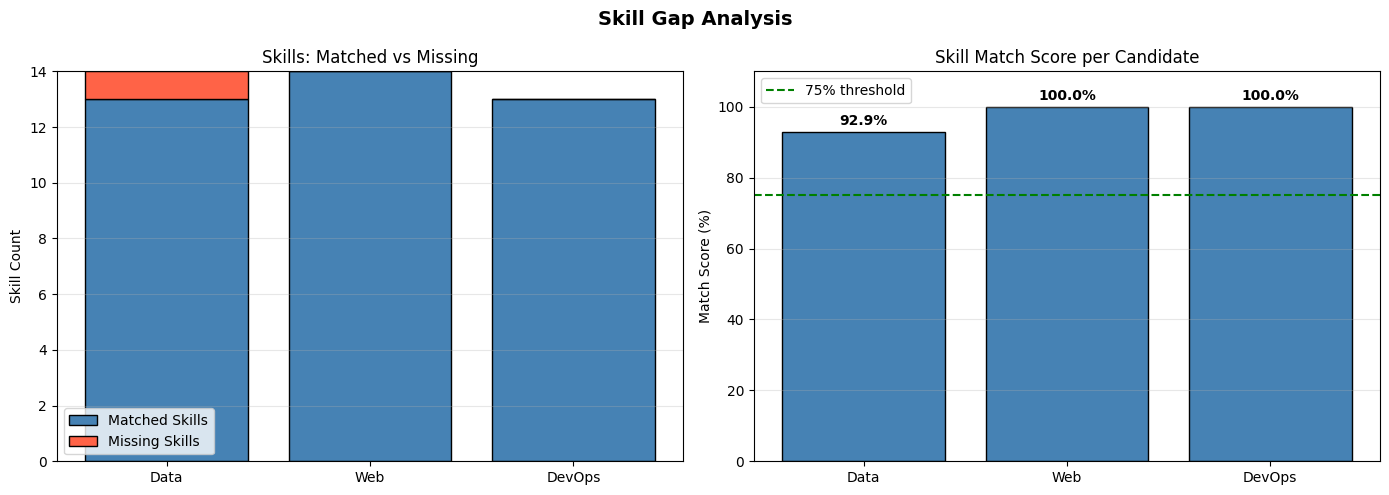

In [35]:
gap_data = [skill_gap_analysis(r, j)
            for _, r, j in demos]
names    = [d[0] for d in demos]
scores   = [g['match_score'] for g in gap_data]
matched  = [g['total_matched'] for g in gap_data]
missing  = [g['total_required'] - g['total_matched']
            for g in gap_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Skill Gap Analysis',
             fontsize=14, fontweight='bold')

# Stacked bar — matched vs missing
x = np.arange(len(names))
axes[0].bar(x, matched, color='steelblue',
            edgecolor='black', label='Matched Skills')
axes[0].bar(x, missing, bottom=matched,
            color='tomato', edgecolor='black',
            label='Missing Skills')
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.split()[0] for n in names])
axes[0].set_ylabel('Skill Count')
axes[0].set_title('Skills: Matched vs Missing')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Match score gauge
colors_sc = ['tomato' if s < 50
              else 'orange' if s < 75
              else 'steelblue' for s in scores]
bars = axes[1].bar([n.split()[0] for n in names],
                   scores,
                   color=colors_sc,
                   edgecolor='black')
for bar, sc in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{sc}%',
                 ha='center', va='bottom',
                 fontweight='bold')
axes[1].set_ylim(0, 110)
axes[1].axhline(75, color='green', linestyle='--',
                label='75% threshold')
axes[1].set_ylabel('Match Score (%)')
axes[1].set_title('Skill Match Score per Candidate')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


 Classification Model Comparison:
                                     Accuracy
SVM (TF-IDF)                           0.7264
Logistic Regression (ST Embeddings)    0.7264
DNN (ST Embeddings)                    0.7042
Random Forest (ST Embeddings)          0.6761
Logistic Regression (TF-IDF)           0.6459


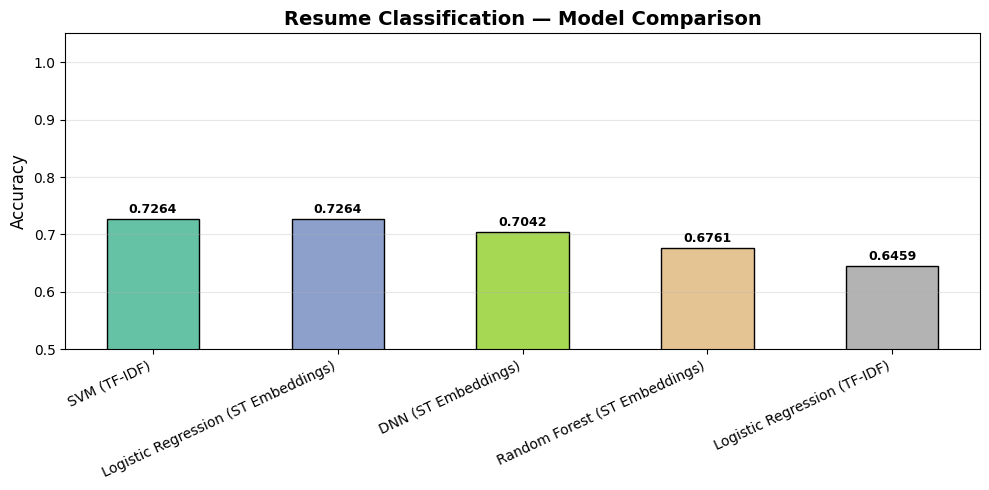

In [36]:
clf_df = (pd.DataFrame(clf_results).T
           .sort_values('Accuracy', ascending=False))

print("\n Classification Model Comparison:")
print(clf_df.to_string())

plt.figure(figsize=(10, 5))
bars = plt.bar(clf_df.index,
               clf_df['Accuracy'],
               color=plt.cm.Set2(
                   np.linspace(0,1,len(clf_df))),
               edgecolor='black', width=0.5)

for bar, val in zip(bars, clf_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.ylim(0.5, 1.05)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Resume Classification — Model Comparison',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [37]:
print("COMPLETE RESUME SCREENING PIPELINE")


def full_pipeline(resume_text, top_jobs=3, top_candidates=5):
    print(" RESUME ANALYSIS REPORT")

    cleaned = preprocess(resume_text)

    # 1. Keywords
    kws = extract_keywords(resume_text, top_n=10)
    print(f"\nTop Keywords:")
    print(f"   {[k[0] for k in kws]}")

    # 2. Skills
    skills = extract_skills(resume_text)
    print(f"\n  Extracted Skills:")
    for cat, sk in skills.items():
        if sk:
            print(f"   {cat:<15}: {sk}")

    # 3. NER
    ents = extract_ner_spacy(resume_text)
    print(f"\n  Named Entities:")
    for label, icon in NER_LABELS.items():
        if label in ents:
            print(f"   {icon:<20}: "
                  f"{list(set(ents[label]))[:3]}")

    # 4. Job Recommendations
    print(f"\n Top {top_jobs} Job Recommendations (ST):")
    recs = recommend_jobs(resume_text, top_n=top_jobs, method='st')
    for _, row in recs.iterrows():
        bar = '█' * int(row['similarity']*25)
        print(f"   {row['rank']}. {row['title']:<25}"
              f"  {row['similarity']:.4f}  {bar}")

    # 5. Best JD match + skill gap
    best_jd_title = recs.iloc[0]['title']
    best_jd_desc  = next(
        j['description'] for j in JOB_DB
        if j['title'] == best_jd_title)
    gap = skill_gap_analysis(resume_text, best_jd_desc)

    print(f"\n Skill Gap vs '{best_jd_title}':")
    print(f"    Matched  : {gap['matched']}")
    print(f"    Missing  : {gap['missing']}")
    print(f"    Score    : {gap['match_score']}%")

    # 6. Classify resume
    r_vec      = st_model.encode([cleaned])
    r_sc       = scaler_dnn.transform(r_vec)
    dnn_p      = dnn_clf.predict(r_sc, verbose=0)[0]
    pred_cat   = le.classes_[np.argmax(dnn_p)]
    pred_conf  = np.max(dnn_p)

    print(f"\n DNN Category Prediction:")
    print(f"   Category   : {pred_cat}")
    print(f"   Confidence : {pred_conf*100:.1f}%")


# Run full pipeline
full_pipeline(test_resume_1)
full_pipeline(test_resume_2)
full_pipeline(test_resume_3)

COMPLETE RESUME SCREENING PIPELINE
 RESUME ANALYSIS REPORT

Top Keywords:
   ['data', 'learning', 'computer', 'experienced', 'scientist', 'years', 'expertise', 'machine', 'deep', 'python']

  Extracted Skills:
   Programming    : ['python', 'sql', 'r']
   ML/AI          : ['machine learning', 'deep learning', 'nlp', 'tensorflow', 'pytorch', 'scikit', 'computer vision', 'bert', 'transformers', 'pandas', 'numpy']
   Data           : ['tableau', 'sql']
   Cloud/DevOps   : ['aws', 'docker']

  Named Entities:
    Person             : ['Docker']
    Organization       : ['Experienced Data Scientist', 'SQL', 'ML']
    Location           : ['Tableau']
    Date               : ['5 years']

 Top 3 Job Recommendations (ST):
   1. Data Scientist             0.8377  ████████████████████
   2. ML Engineer                0.7960  ███████████████████
   3. Software Engineer          0.3380  ████████

 Skill Gap vs 'Data Scientist':
    Matched  : ['computer vision', 'deep learning', 'machine learning'

In [38]:
print(" PROJECT SUMMARY")

print(f"   Dataset       : Resume Dataset (Kaggle)")
print(f"   Total Resumes : {len(df)}")
print(f"    Categories    : {df['Category'].nunique()}")
print(f"   TF-IDF Feats  : {tfidf_matrix.shape[1]}")
print(f"   ST Emb Dim    : {st_embeddings.shape[1]}")
print(f"   BERT Emb Dim  : {np.array(bert_embs).shape[1]}")

print(f"\n   Classification Results:")
for model, scores in sorted(clf_results.items(),
                             key=lambda x: -x[1]['Accuracy']):
    print(f"    {model:<35} {scores['Accuracy']:.4f}")

print(f"\n   Best Classifier : "
      f"{max(clf_results, key=lambda x: clf_results[x]['Accuracy'])}")

print("\n Resume Screening Project Complete!")

 PROJECT SUMMARY
   Dataset       : Resume Dataset (Kaggle)
   Total Resumes : 2484
    Categories    : 24
   TF-IDF Feats  : 15000
   ST Emb Dim    : 384
   BERT Emb Dim  : 768

   Classification Results:
    SVM (TF-IDF)                        0.7264
    Logistic Regression (ST Embeddings) 0.7264
    DNN (ST Embeddings)                 0.7042
    Random Forest (ST Embeddings)       0.6761
    Logistic Regression (TF-IDF)        0.6459

   Best Classifier : SVM (TF-IDF)

 Resume Screening Project Complete!
